## **eda practice**

In [48]:
import pandas as pd
import numpy as np

import category_encoders as ce
from sklearn import preprocessing

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


In [49]:
heart = pd.read_csv('data/heart.csv', sep=',')
heart.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### data engineering and data encoding

In [50]:
# onehot encoding feature elder then 60
heart['age'] = heart['age'].astype(int)
heart['old'] = heart['age'].apply(lambda x: 1 if x > 60 else 0)
# add new feature trestbps_mean
# cond for male
cond_male_1 = (heart['sex'] == 1) & (heart['age'] <= 20)
cond_male_2 = (heart['sex'] == 1) & (heart['age'] > 20) & (heart['age'] < 31)
cond_male_3 = (heart['sex'] == 1) & (heart['age'] > 30) & (heart['age'] < 41)
cond_male_4 = (heart['sex'] == 1) & (heart['age'] > 40) & (heart['age'] < 51)
cond_male_5 = (heart['sex'] == 1) & (heart['age'] > 50) & (heart['age'] < 61)
cond_male_6 = (heart['sex'] == 1) & (heart['age'] > 60)
# cond for female
cond_female_1 = (heart['sex'] == 0) & (heart['age'] <= 20)
cond_female_2 = (heart['sex'] == 0) & (heart['age'] > 20) & (heart['age'] < 31)
cond_female_3 = (heart['sex'] == 0) & (heart['age'] > 30) & (heart['age'] < 41)
cond_female_4 = (heart['sex'] == 0) & (heart['age'] > 40) & (heart['age'] < 51)
cond_female_5 = (heart['sex'] == 0) & (heart['age'] > 50) & (heart['age'] < 61)
cond_female_6 = (heart['sex'] == 0) & (heart['age'] > 60)
# choise for male
chos_male_1 = 123
chos_male_2 = 126
chos_male_3 = 129
chos_male_4 = 135
chos_male_5 = 142
chos_male_6 = 142
# choise for female
chos_female_1 = 116
chos_female_2 = 120
chos_female_3 = 127
chos_female_4 = 137
chos_female_5 = 144
chos_female_6 = 159
# select
heart['trestbps_mean'] = np.select(condlist=[cond_male_1, cond_male_2, cond_male_3, cond_male_4, cond_male_5, cond_male_6,
                                             cond_female_1, cond_female_2, cond_female_3, cond_female_4, cond_female_5, cond_female_6],
                                    choicelist=[chos_male_1, chos_male_2, chos_male_3, chos_male_4, chos_male_5, chos_male_6,
                                                chos_female_1, chos_female_2, chos_female_3, chos_female_4, chos_female_5, chos_female_6],
                                                default=pd.NA)
# OneHot Encoding 
onehot = ce.OneHotEncoder(cols=['cp', 'restecg', 'slope', 'ca', 'thal'])
onehot_code = onehot.fit_transform(heart[['cp', 'restecg', 'slope', 'ca', 'thal']])
heart = heart.drop(labels=['cp', 'restecg', 'slope', 'ca', 'thal'], axis=1)
heart = pd.concat([heart, onehot_code], axis=1)

### data normalization

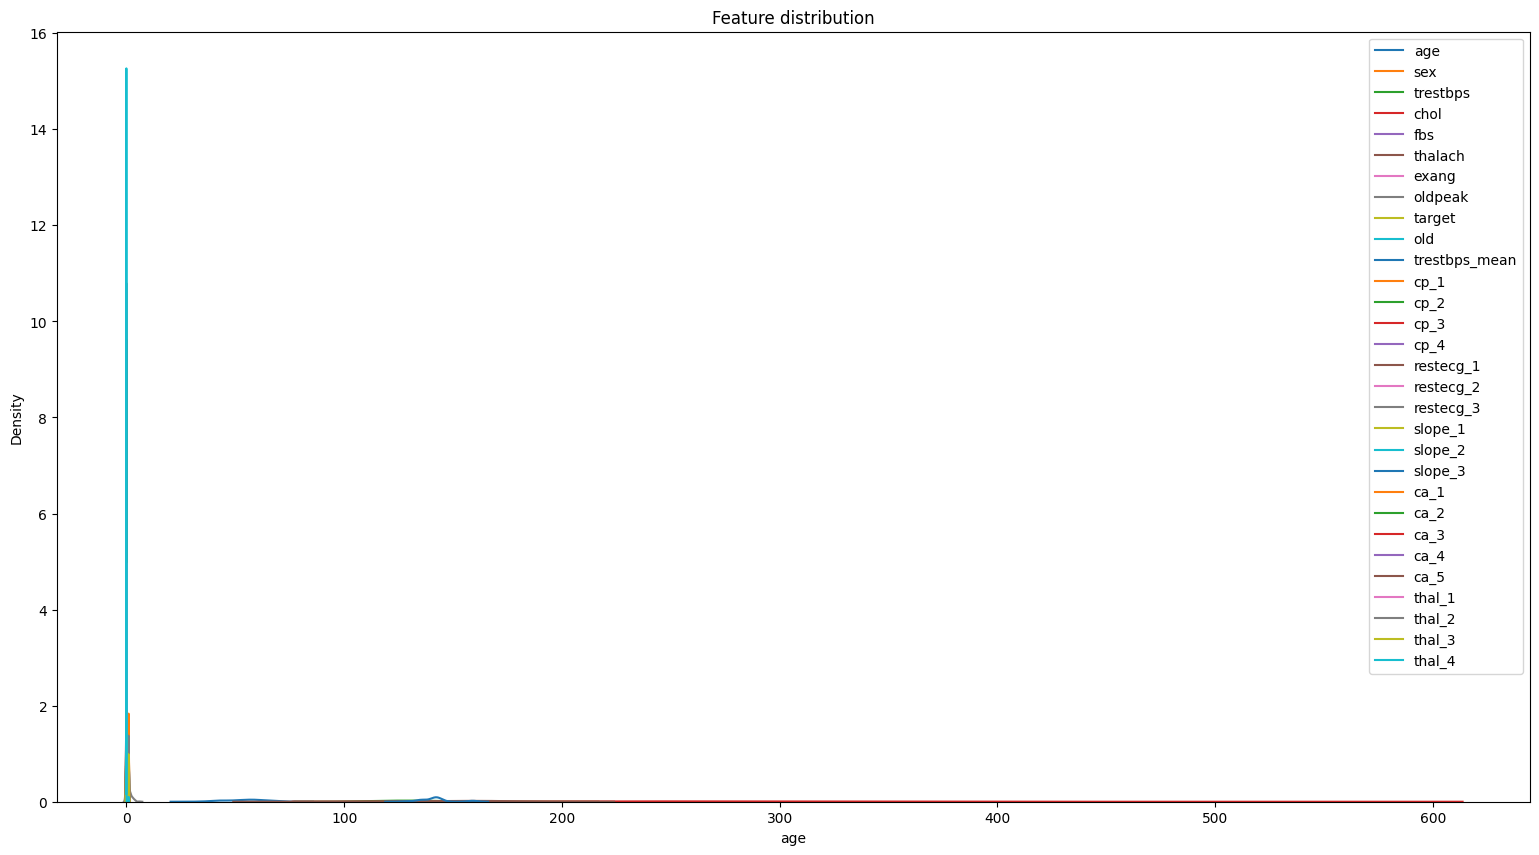

In [51]:
fig, ax = plt.subplots(ncols=1, figsize=(19, 10))
ax.set_title('Feature distribution')
for col in heart.columns:
    sns.kdeplot(heart[col], ax=ax, label=col)
plt.legend();


features distribution is not normal

In [ ]:
robus  = preprocessing.RobustScaler()
columns_name = heart.columns
heart = robus.fit_transform(heart)
heart = pd.DataFrame(data=heart, columns=columns_name)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,old,...,slope_3,ca_1,ca_2,ca_3,ca_4,ca_5,thal_1,thal_2,thal_3,thal_4
0,0.592593,0.0,0.75,-0.110236,1.0,-0.092308,0.0,0.9375,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0
1,-1.333333,0.0,0.00,0.157480,0.0,1.046154,0.0,1.6875,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.037037,-1.0,0.00,-0.566929,0.0,0.584615,0.0,0.3750,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.074074,0.0,-0.50,-0.062992,0.0,0.769231,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.148148,-1.0,-0.50,1.795276,0.0,0.307692,1.0,-0.1250,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.148148,-1.0,0.50,0.015748,0.0,-0.923077,1.0,-0.3750,-1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0
299,-0.740741,0.0,-1.00,0.377953,0.0,-0.646154,0.0,0.2500,-1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0
300,0.962963,0.0,0.70,-0.740157,1.0,-0.369231,0.0,1.6250,-1.0,1.0,...,1.0,-1.0,1.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0
301,0.148148,0.0,0.00,-1.716535,0.0,-1.169231,1.0,0.2500,-1.0,0.0,...,1.0,-1.0,0.0,1.0,0.0,0.0,0.0,-1.0,1.0,0.0


### feature selection

<Axes: >

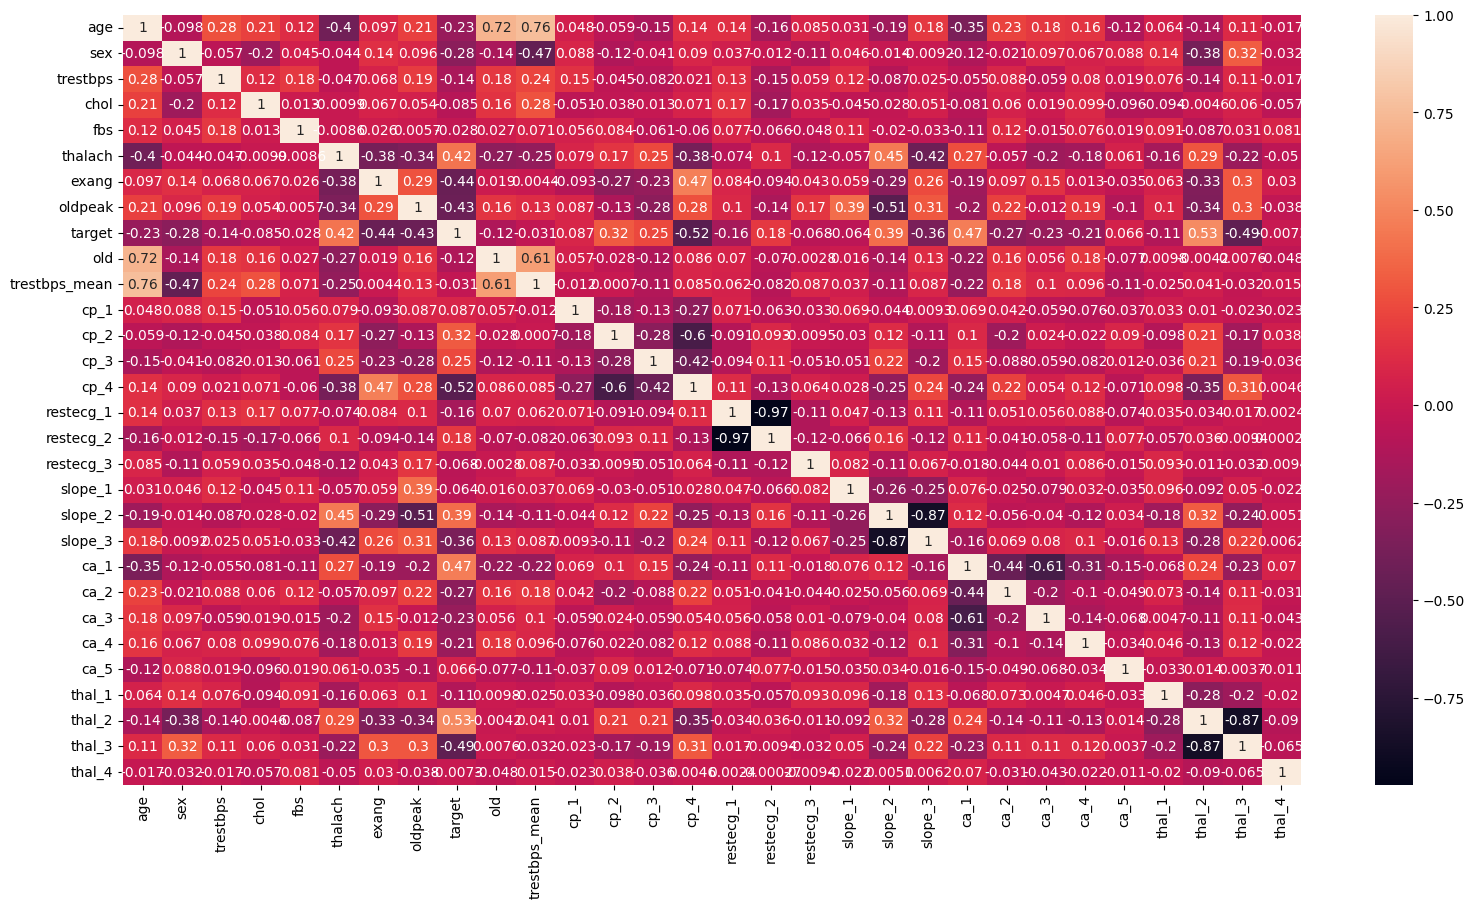

In [58]:
fig = plt.figure(figsize=(19,10))
sns.heatmap(data=heart.corr(), annot=True)